### SMAI-Assignment-1

Yogesh Krishna, 2024102035

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [47]:
df = pd.read_csv('essays(in).csv')

In [48]:
df.sample(5)

,essay_id,full_text,score
856,0dabca9,I claim that the author suggests that studying...,3
13403,c4b5c88,The Face of Mars was discovered by one of NASA...,4
15539,e4fff57,A new technology called Facial Action Coding S...,4
10306,9841c2a,I say we should keep the Electoral collage. Th...,3
10065,949e0f0,Why do we have emotions? Why were we given tho...,5


In [49]:
df.drop(columns = 'essay_id', inplace = True)

In [50]:
df.duplicated().sum()

np.int64(0)

In [51]:
df.isnull().sum()

full_text    0
score        0
dtype: int64

In [52]:
df.info()
print(df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 17307 entries, 0 to 17306
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   full_text  17307 non-null  str  
 1   score      17307 non-null  int64
dtypes: int64(1), str(1)
memory usage: 34.4 MB
(17307, 2)


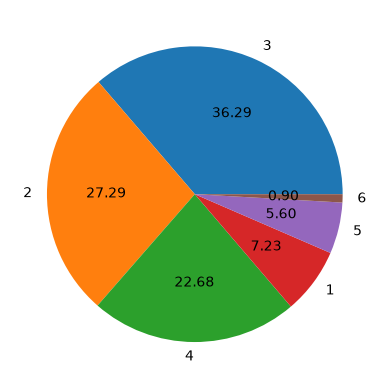

In [53]:
df['score'].value_counts()
plt.pie(df['score'].value_counts(), labels = ['3', '2', '4', '1', '5', '6'], autopct='%0.2f')
plt.show()

In [54]:
import hashlib
username = "yogesh.krishna"  # part before '@'
seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)

In [58]:
import string
remove_punct = str.maketrans('', '', string.punctuation)
df['word_count'] = (df['full_text'].str.lower().str.translate(remove_punct)).str.split().str.len()

df['sentence_count'] = (
    df['full_text'].str.count(r'\.') +
    df['full_text'].str.count('!') +
    df['full_text'].str.count(r'\?')
).clip(lower=1)

In [59]:
df.head()

,full_text,score,word_count,sentence_count
0,Many people have car where they live. The thin...,3,498,13
1,I am a scientist at NASA that is discussing th...,3,328,23
2,People always wish they had the same technolog...,4,547,24
3,"We all heard about Venus, the planet without a...",4,445,24
4,"Dear, State SenatorThis is a letter to argue i...",3,368,15


In [60]:
def extract_all_bins(text):
    text = str(text)

    # 1. SENTENCE BINS (Uses raw text with punctuation)
    temp_text = text.replace('!', '.').replace('?', '.')
    sentences = [s.strip() for s in temp_text.split('.') if s.strip()]
    
    # Word count per individual sentence
    sent_lengths = [len(s.split()) for s in sentences]
    
    num_short_sentences = sum(1 for l in sent_lengths if l <= 10) # 1-10 words
    num_med_sentences = sum(1 for l in sent_lengths if 11 <= l <= 25) # 11-25 words
    num_long_sentences = sum(1 for l in sent_lengths if l > 25) # 26+ words

    # 2. WORD BINS (cleaned text without punctuation)
    clean_text = text.translate(remove_punct)
    words = clean_text.split()
    
    num_short_words = sum(1 for w in words if len(w) <= 3) # 1-3 chars
    num_med_words = sum(1 for w in words if 4 <= len(w) <= 7) # 4-7 chars
    num_long_words  = sum(1 for w in words if len(w) >= 8) # 8+ chars

    return pd.Series({
        'short_words': num_short_words,
        'med_words': num_med_words,
        'long_words': num_long_words,
        'short_sentences': num_short_sentences,
        'med_sentences': num_med_sentences,
        'long_sentences': num_long_sentences
    })

feature_matrix = df['full_text'].apply(extract_all_bins)
df = pd.concat([df, feature_matrix], axis=1)

In [61]:
df.head()

,full_text,score,word_count,sentence_count,short_words,med_words,long_words,short_sentences,med_sentences,long_sentences
0,Many people have car where they live. The thin...,3,498,13,210,247,41,2,5,6
1,I am a scientist at NASA that is discussing th...,3,328,23,155,143,30,6,13,2
2,People always wish they had the same technolog...,4,547,24,229,253,65,1,12,11
3,"We all heard about Venus, the planet without a...",4,445,24,172,189,84,2,11,8
4,"Dear, State SenatorThis is a letter to argue i...",3,368,15,161,142,65,1,11,4


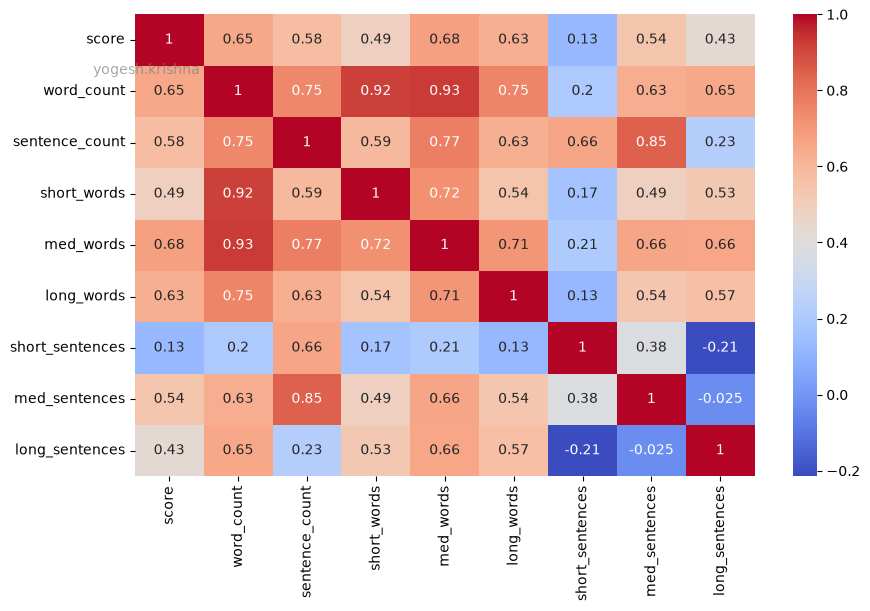

In [72]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.text(
    0.95, 0.95, username,
    ha='right', va='top',
    color='gray', 
    alpha=0.7
)
plt.show()